**Basics of R**

In [2]:
a <- 1

In [3]:
a

[1] 1

In [4]:
b <- 3
a + b

[1] 4

In [5]:
c <-2
b/c

[1] 1.5

In [6]:
my_text <- "Joshua"

In [7]:
class(my_text)

[1] "character"

In [8]:
bool <- TRUE
class(bool)

[1] "logical"

In [9]:
die <- 1:6
class(die)

[1] "integer"

In [10]:
die

[1] 1 2 3 4 5 6

In [11]:
die + 1:2

[1] 2 4 4 6 6 8

In [12]:
ls()

[1] "a"       "b"       "bool"    "c"       "die"     "my_text"

In [13]:
round(3.142)

[1] 3

In [14]:
factorial(4)

[1] 24

In [15]:
round(mean(1:6))

[1] 4

In [16]:
dice <- sample(die, size = 2, replace = TRUE)
dice
sum(dice)

[1] 4 5

[1] 9

In [17]:
roll <- function(){
  die <- 1:6
  dice <- sample(die, size = 2, replace=TRUE)
  dice
  sum(dice)
}

In [18]:
roll()

[1] 4

In [19]:
roll2 <- function(bones){
  dice <- sample(bones, size = 2, replace = TRUE)
  sum (dice)
}

In [20]:
roll2(1:6)

[1] 5

*using packages*

In [21]:
library("ggplot2")

In [22]:
qplot

function (x, y, ..., data, facets = NULL, margins = FALSE, geom = "auto", 
    xlim = c(NA, NA), ylim = c(NA, NA), log = "", main = NULL, 
    xlab = NULL, ylab = NULL, asp = NA, stat = deprecated(), 
    position = deprecated()) 
{
    deprecate_warn0("3.4.0", "qplot()")
    caller_env <- parent.frame()
    if (lifecycle::is_present(stat)) 
        lifecycle::deprecate_stop("2.0.0", "qplot(stat)")
    if (lifecycle::is_present(position)) 
        lifecycle::deprecate_stop("2.0.0", "qplot(position)")
    check_character(geom)
    exprs <- enquos(x = x, y = y, ...)
    is_missing <- vapply(exprs, quo_is_missing, logical(1))
    is_constant <- (!names(exprs) %in% ggplot_global$all_aesthetics) | 
        vapply(exprs, quo_is_call, logical(1), name = "I")
    mapping <- class_mapping(exprs[!is_missing & !is_constant], 
        env = parent.frame())
    consts <- exprs[is_constant]
    aes_names <- names(mapping)
    mapping <- rename_aes(mapping)
    if (is.null(xlab)) {
        if (quo_is_missing(exprs$x)) {
            xlab <- ""
        }
        else {
            xlab <- as_label(exprs$x)
        }
    }
    if (is.null(ylab)) {
        if (quo_is_missing(exprs$y)) {
            ylab <- ""
        }
        else {
            ylab <- as_label(exprs$y)
        }
    }
    if (missing(data)) {
        data <- data_frame0()
        facetvars <- all.vars(facets)
        facetvars <- facetvars[facetvars != "."]
        names(facetvars) <- facetvars
        facetsdf <- as.data.frame(mget(facetvars, envir = caller_env))
        if (nrow(facetsdf)) 
            data <- facetsdf
    }
    if ("auto" %in% geom) {
        if ("sample" %in% aes_names) {
            geom[geom == "auto"] <- "qq"
        }
        else if (missing(y)) {
            x <- eval_tidy(mapping$x, data, caller_env)
            if (is_discrete(x)) {
                geom[geom == "auto"] <- "bar"
            }
            else {
                geom[geom == "auto"] <- "histogram"
            }
            if (is.null(ylab)) 
                ylab <- "count"
        }
        else {
            if (missing(x)) {
                mapping$x <- quo(seq_along(!!mapping$y))
            }
            geom[geom == "auto"] <- "point"
        }
    }
    p <- ggplot(data, mapping, environment = caller_env)
    if (is.null(facets)) {
        p <- p + facet_null()
    }
    else if (is_formula(facets) && length(facets) == 2) {
        p <- p + facet_wrap(facets)
    }
    else {
        p <- p + facet_grid(rows = deparse(facets), margins = margins)
    }
    if (!is.null(main)) 
        p <- p + ggtitle(main)
    for (g in geom) {
        params <- lapply(consts, eval_tidy)
        p <- p + do.call(paste0("geom_", g), params)
    }
    logv <- function(var) var %in% strsplit(log, "")[[1]]
    if (logv("x")) 
        p <- p + scale_x_log10()
    if (logv("y")) 
        p <- p + scale_y_log10()
    if (!is.na(asp)) 
        p <- p + theme(aspect.ratio = asp)
    if (!missing(xlab)) 
        p <- p + xlab(xlab)
    if (!missing(ylab)) 
        p <- p + ylab(ylab)
    if (!missing(xlim) && !all(is.na(xlim))) 
        p <- p + xlim(xlim)
    if (!missing(ylim) && !all(is.na(ylim))) 
        p <- p + ylim(ylim)
    p
}
<bytecode: 0x0000018e3b38f540>
<environment: namespace:ggplot2>

In [23]:
x <- c(-1, -0.8,-0.6,-0.4, -0.2,0,0.2, 0.4, 0.6, 0.8,1)
x

[1] -1.0 -0.8 -0.6 -0.4 -0.2  0.0  0.2  0.4  0.6  0.8  1.0

In [24]:
y <- x ^3
y

[1] -1.000 -0.512 -0.216 -0.064 -0.008  0.000  0.008  0.064  0.216  0.512
[11]  1.000

In [25]:
args(qplot)

function (x, y, ..., data, facets = NULL, margins = FALSE, geom = "auto", 
    xlim = c(NA, NA), ylim = c(NA, NA), log = "", main = NULL, 
    xlab = NULL, ylab = NULL, asp = NA, stat = deprecated(), 
    position = deprecated()) 
NULL

Warning message:
"`qplot()` was deprecated in ggplot2 3.4.0."


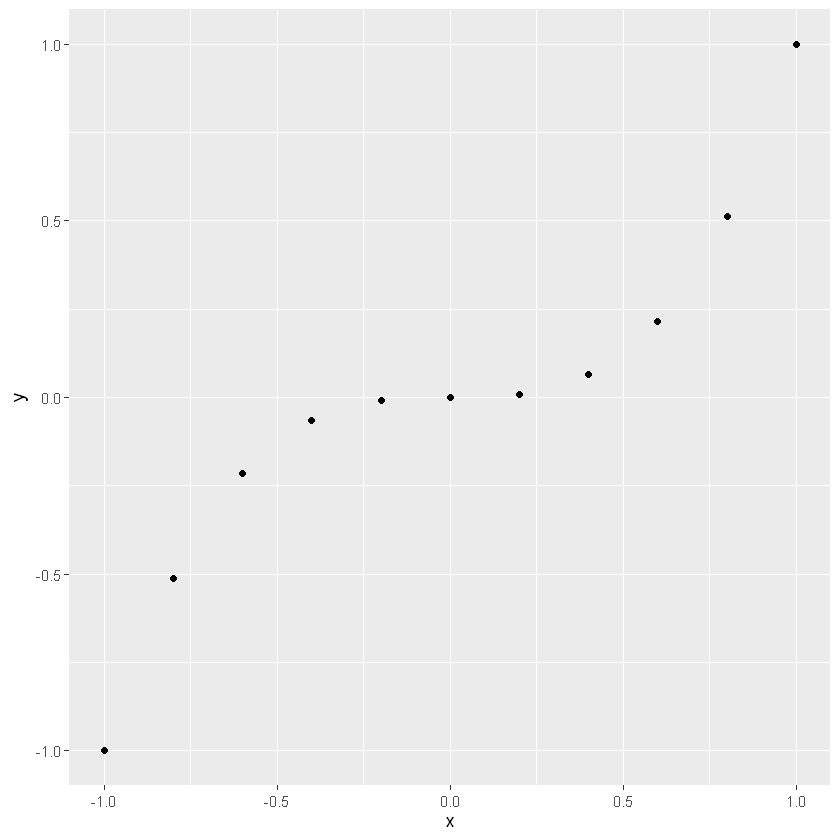

In [26]:
qplot(x,y)

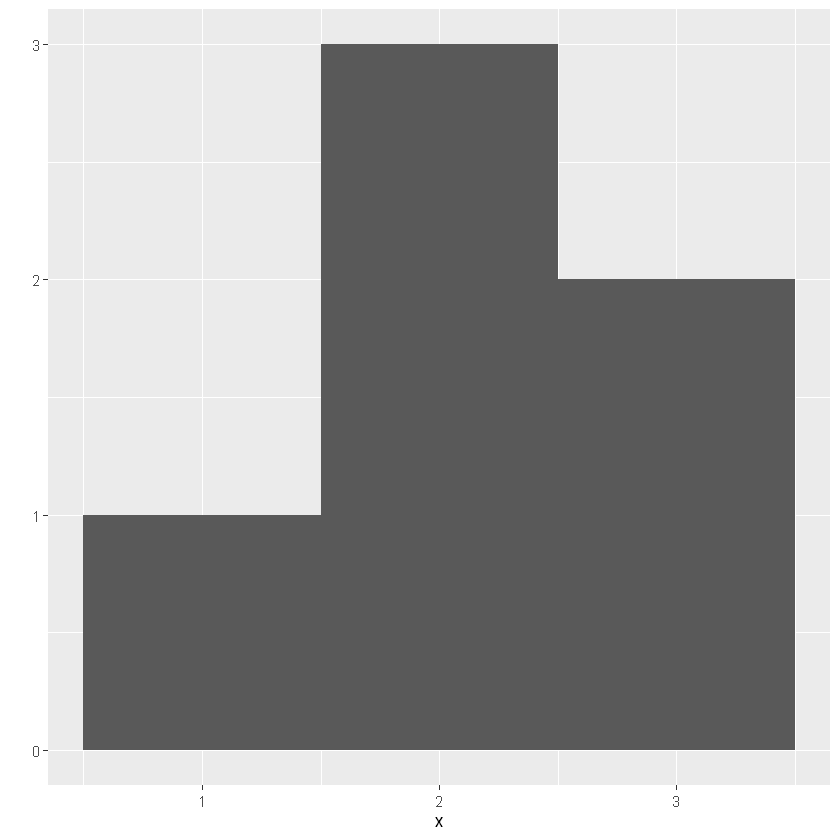

In [27]:
x <- c(1,2,2,2,3,3)
qplot(x, binwidth=1)

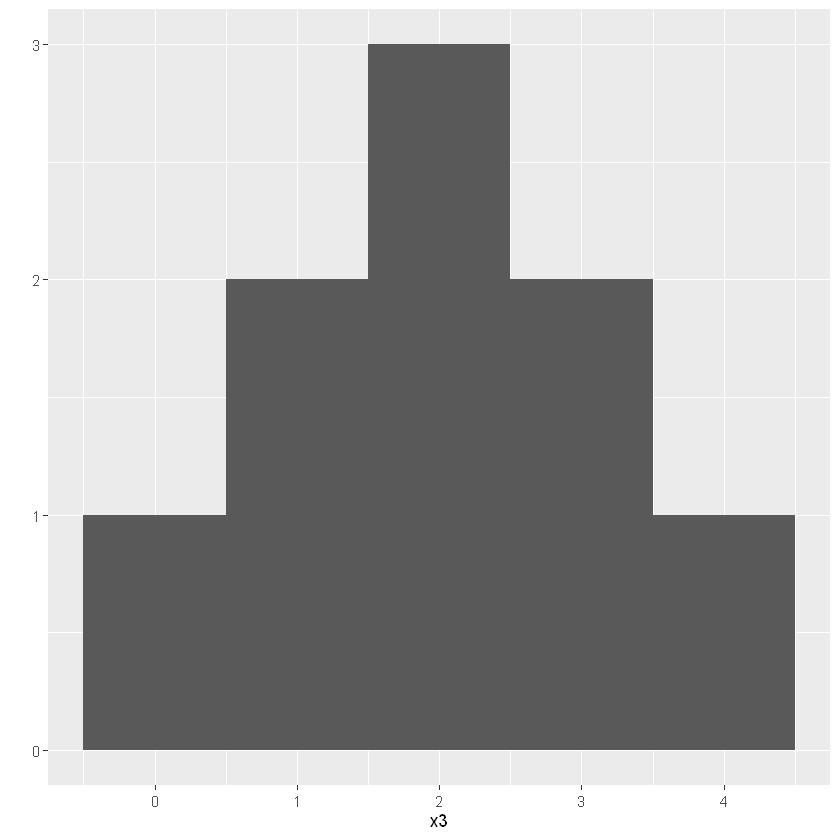

In [28]:
x3 <- c(0,1,1,2,2,2,3,3,4)
qplot(x3, binwidth=1)

In [29]:
replicate(10, roll())

[1]  8 11  6  3  6  9  9  7  5 11

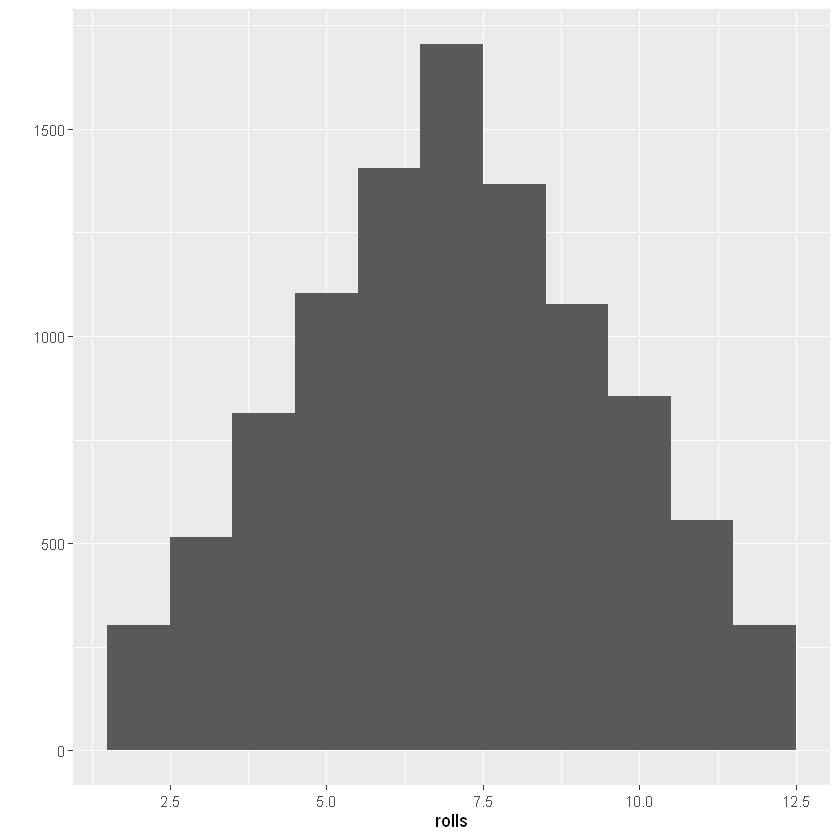

In [30]:
rolls <- replicate(10000, roll())
qplot(rolls, binwidth=1)

In [31]:
roll3 <- function(){
  die <- 1:6
  dice <- sample(die, size = 2, replace = TRUE, prob = c(1/8,1/8,1/8,1/8,1/8,3/8))
  sum(dice)
}

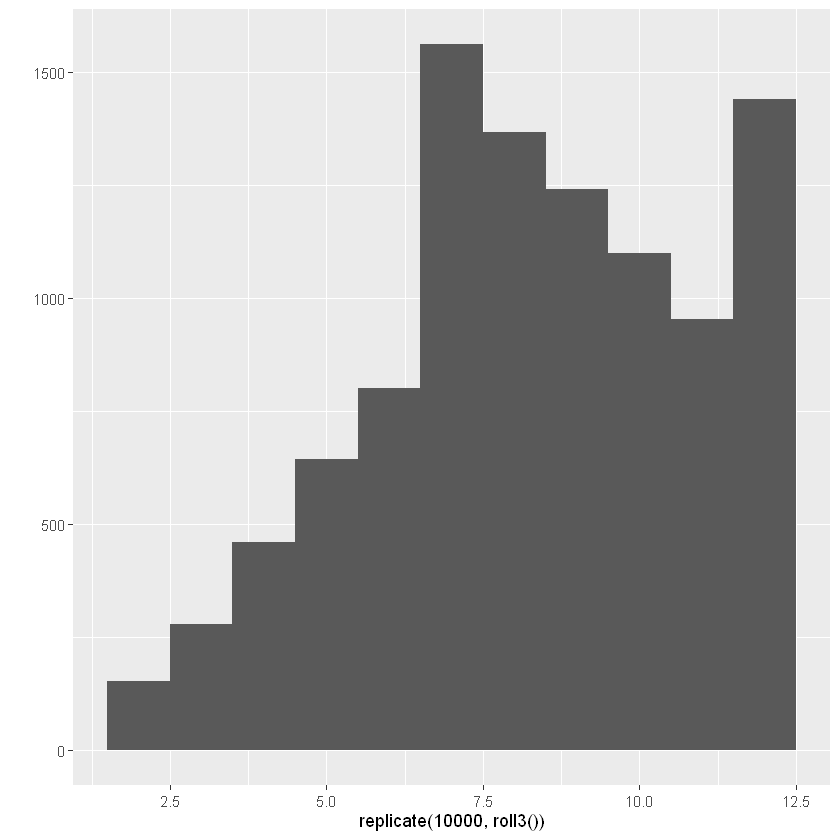

In [32]:
qplot(replicate(10000,roll3()), binwidth=1)

In [33]:
length(dice)

[1] 2

In [34]:
hand = c("ace", "king","queen", "jack", "ten")
typeof(hand)

[1] "character"

In [35]:
attributes(die)

NULL

In [36]:
names(die)

NULL

In [37]:
names(die)<- c("one", "two", "three", "four", "five", "six")
names(die)

[1] "one"   "two"   "three" "four"  "five"  "six"

In [38]:
die+1

one   two three  four  five   six 
    2     3     4     5     6     7

In [39]:
dim(die) <- c(3,2)
die

1,4
2,5
3,6


In [40]:
m <- matrix(die, nrow = 2, byrow = T)
m

1,2,3
4,5,6


In [41]:
ar <- array(c(11:14, 21:24, 31:34), dim = c(2,2,3))
ar <- matrix(ar, nrow = 2)
ar

11,13,21,23,31,33
12,14,22,24,32,34


In [42]:
hand <- c("ace", "king", "queen","jack", "ten", "spades", "spades", "spades", "spades","spades")
card <- matrix(hand, nrow = 5)
card

ace,spades
king,spades
queen,spades
jack,spades
ten,spades


In [43]:
attributes(card)

$dim
[1] 5 2

In [44]:
now = Sys.time()
typeof(now)

[1] "double"

In [45]:
class(now)

[1] "POSIXct" "POSIXt"

In [46]:
gender <- factor(c("male", "female","female", "male"))

attributes(gender)

$levels
[1] "female" "male"  

$class
[1] "factor"

In [47]:
list1 <- list(100:105, "R", list(T,F))
list1

[[1]]
[1] 100 101 102 103 104 105

[[2]]
[1] "R"

[[3]]
[[3]][[1]]
[1] TRUE

[[3]][[2]]
[1] FALSE

In [48]:
df <- data.frame(face=c("ace", "two", "six"), suit = c("clubs", "clubs", "clubs"), value = c(1,2,3))
df

face,suit,value
<chr>,<chr>,<dbl>
ace,clubs,1
two,clubs,2
six,clubs,3


In [49]:
str(df)

'data.frame':	3 obs. of  3 variables:
 $ face : chr  "ace" "two" "six"
 $ suit : chr  "clubs" "clubs" "clubs"
 $ value: num  1 2 3


In [50]:
df <- read.csv("../data/deck.csv", header = TRUE, stringsAsFactors = FALSE)
str(df)

'data.frame':	52 obs. of  3 variables:
 $ face : chr  "king" "queen" "jack" "ten" ...
 $ suit : chr  "spades" "spades" "spades" "spades" ...
 $ value: int  13 12 11 10 9 8 7 6 5 4 ...


In [51]:
head(df)

,face,suit,value
,<chr>,<chr>,<int>
1,king,spades,13
2,queen,spades,12
3,jack,spades,11
4,ten,spades,10
5,nine,spades,9
6,eight,spades,8


In [52]:
getwd()

[1] "c:/Users/Joshua/work_projects/learningR/code"

In [53]:
write.csv(df, file="../data/cards.csv", row.names=FALSE)

In [54]:
deck <- read.csv("../data/cards.csv", stringsAsFactors = FALSE, header = TRUE)
head(deck)

,face,suit,value
,<chr>,<chr>,<int>
1,king,spades,13
2,queen,spades,12
3,jack,spades,11
4,ten,spades,10
5,nine,spades,9
6,eight,spades,8


In [55]:
deal <- function(cards) {
    cards[1,]
}
deal(deck)

,face,suit,value
,<chr>,<chr>,<int>
1,king,spades,13


In [56]:
shuffle <- function(cards) {
    rand <- sample(1:52, size=52)
    cards[rand,]
}
head(shuffle(deck))

,face,suit,value
,<chr>,<chr>,<int>
8,six,spades,6
47,six,hearts,6
7,seven,spades,7
39,ace,diamonds,1
35,five,diamonds,5
33,seven,diamonds,7


In [57]:
deal(shuffle(deck))

,face,suit,value
,<chr>,<chr>,<int>
28,queen,diamonds,12


**DAY 2**

In [58]:
deck$value

[1] 13 12 11 10  9  8  7  6  5  4  3  2  1 13 12 11 10  9  8  7  6  5  4  3  2
[26]  1 13 12 11 10  9  8  7  6  5  4  3  2  1 13 12 11 10  9  8  7  6  5  4  3
[51]  2  1

In [59]:
mean(deck$value)

[1] 7

In [60]:
median(deck$value)

[1] 7

In [61]:
lst = list(numbers=c(1,4), logical=TRUE, strings=c("a", "b", "c"))
lst

$numbers
[1] 1 4

$logical
[1] TRUE

$strings
[1] "a" "b" "c"

In [62]:
sum(lst$numbers)

[1] 5

In [63]:
deck2 <- deck
head(deck2)

,face,suit,value
,<chr>,<chr>,<int>
1,king,spades,13
2,queen,spades,12
3,jack,spades,11
4,ten,spades,10
5,nine,spades,9
6,eight,spades,8


In [64]:
vec <- c(0,0,0,0,0,0)
vec[c(1,3,5)] <- c(1,1,1)
vec[4:6] <- vec[4:6] +1
vec[7]<- 0
vec

[1] 1 0 1 1 2 1 0

In [65]:
deck2$value[c(13,26,39,52)]<-14
head(deck2,13)

,face,suit,value
,<chr>,<chr>,<dbl>
1,king,spades,13
2,queen,spades,12
3,jack,spades,11
4,ten,spades,10
5,nine,spades,9
6,eight,spades,8
7,seven,spades,7
8,six,spades,6
9,five,spades,5


In [66]:
sum(deck$face=="ace")

[1] 4

In [67]:
deck3 <- shuffle(deck)
head(deck3, 13)

,face,suit,value
,<chr>,<chr>,<int>
10,four,spades,4
30,ten,diamonds,10
51,two,hearts,2
43,ten,hearts,10
2,queen,spades,12
48,five,hearts,5
13,ace,spades,1
20,seven,clubs,7
21,six,clubs,6


In [68]:
sum(deck3$value[deck3$face=="ace"])

[1] 4

In [69]:
deck3$value[deck3$face=="ace"] <- 14
head(deck3,13)

,face,suit,value
,<chr>,<chr>,<dbl>
10,four,spades,4
30,ten,diamonds,10
51,two,hearts,2
43,ten,hearts,10
2,queen,spades,12
48,five,hearts,5
13,ace,spades,14
20,seven,clubs,7
21,six,clubs,6


In [70]:
deck4 <- deck
deck4$value<-0
head(deck4, 13)

,face,suit,value
,<chr>,<chr>,<dbl>
1,king,spades,0
2,queen,spades,0
3,jack,spades,0
4,ten,spades,0
5,nine,spades,0
6,eight,spades,0
7,seven,spades,0
8,six,spades,0
9,five,spades,0


In [71]:
sum(deck4$suit=="hearts")

[1] 13

In [72]:
queen<-deck4$suit =="spades" & deck4$face=="queen"


In [73]:
deck4[queen,]

,face,suit,value
,<chr>,<chr>,<dbl>
2,queen,spades,0


In [74]:
deck4$value[queen]<-13
deck4[queen,]

,face,suit,value
,<chr>,<chr>,<dbl>
2,queen,spades,13


In [75]:
deck5 <- deck
head(deck5, 13)

,face,suit,value
,<chr>,<chr>,<int>
1,king,spades,13
2,queen,spades,12
3,jack,spades,11
4,ten,spades,10
5,nine,spades,9
6,eight,spades,8
7,seven,spades,7
8,six,spades,6
9,five,spades,5


In [76]:
facecard <- deck5$face %in% c("king", "queen", "jack")

In [77]:
deck5[facecard,]

,face,suit,value
,<chr>,<chr>,<int>
1,king,spades,13
2,queen,spades,12
3,jack,spades,11
14,king,clubs,13
15,queen,clubs,12
16,jack,clubs,11
27,king,diamonds,13
28,queen,diamonds,12
29,jack,diamonds,11


In [78]:
deck5$value[facecard] <- 10
head(deck5)

,face,suit,value
,<chr>,<chr>,<dbl>
1,king,spades,10
2,queen,spades,10
3,jack,spades,10
4,ten,spades,10
5,nine,spades,9
6,eight,spades,8


In [79]:
ace <- deck5$face =="ace"
sum(ace)

[1] 4

In [80]:
1+ NA

[1] NA

In [81]:
c(NA,1:50)

[1] NA  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
[26] 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49
[51] 50

In [82]:
mean(c(NA,1:50))

[1] NA

In [83]:
mean(c(NA, 1:50), na.rm = TRUE)

[1] 25.5

In [84]:
is.na(NA)

[1] TRUE

In [85]:
vec <- c(1,2,3,NA)
is.na(vec)

[1] FALSE FALSE FALSE  TRUE

In [86]:
deck5$value[deck5$face=="ace"]<-NA

In [87]:
head(deck5,13)

,face,suit,value
,<chr>,<chr>,<dbl>
1,king,spades,10
2,queen,spades,10
3,jack,spades,10
4,ten,spades,10
5,nine,spades,9
6,eight,spades,8
7,seven,spades,7
8,six,spades,6
9,five,spades,5


**DAY 3**

In [88]:
get_symbols <- function(){
    wheel <- c("DD", "7", "BBB", "BB", "B", "C", "0")
    sample(wheel, size = 3, replace = TRUE,prob = c(0.03,0.03,0.06,0.1,0.25,0.01,0.52))
}
get_symbols()

[1] "0" "7" "0"

In [89]:
num<-2
if(num < 0){
    num<-num+1
} else {
   num<- num-1
}
num

[1] 1

In [90]:
symbol <- c("B", "B", "B")
symbol[1]==symbol[2] & symbol[2]==symbol[3]

[1] TRUE

In [91]:
all(symbol==symbol[1])

[1] TRUE

In [92]:
length(unique(symbol)) ==1

[1] TRUE

**DAY 4**

In [93]:
head(deck)

,face,suit,value
,<chr>,<chr>,<int>
1,king,spades,13
2,queen,spades,12
3,jack,spades,11
4,ten,spades,10
5,nine,spades,9
6,eight,spades,8


In [94]:
attributes(deck)

$names
[1] "face"  "suit"  "value"

$class
[1] "data.frame"

$row.names
 [1]  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
[26] 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50
[51] 51 52

In [95]:
names(deck)

[1] "face"  "suit"  "value"

In [97]:
levels(deck) <- c("level 1", "level 2", "level 3")
attributes(deck)

$names
[1] "face"  "suit"  "value"

$class
[1] "data.frame"

$row.names
 [1]  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
[26] 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50
[51] 51 52

$levels
[1] "level 1" "level 2" "level 3"

In [98]:
chars <-vector(length = 4)
words <- c("My", "fifth", "day", "here")
for (i in 1:4){
    chars[i] <- words[i]
}
chars

[1] "My"    "fifth" "day"   "here"